In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import joblib

In [2]:
df = pd.read_csv("overtime_dataset.csv")
df.head()

,record_id,date,employee_id,department,location,manager_id,shift_type,contract_type,employee_tenure_months,base_hourly_rate_usd,...,month,quarter,year,is_weekend,is_holiday_week,is_peak_season,team_size,absence_rate,workload_index,prior_week_overtime_hours
0,REC00001,2022-01-01,EMP1221,Logistics,Plant C,MGR012,Day,Full-time,144,32.23,...,1,1,2022,1,1,1,36,0.147,8.2,3.92
1,REC00002,2022-01-02,EMP1876,Security,Plant B,MGR020,Split,Full-time,179,21.26,...,1,1,2022,1,1,1,15,0.033,6.8,18.46
2,REC00003,2022-01-03,EMP2415,IT Support,Plant C,MGR012,Night,Full-time,195,39.86,...,1,1,2022,0,1,1,17,0.259,3.5,5.36
3,REC00004,2022-01-04,EMP1678,Customer Service,Plant B,MGR003,Rotating,Full-time,92,39.45,...,1,1,2022,0,1,1,15,0.214,6.1,0.09
4,REC00005,2022-01-05,EMP2197,Manufacturing,Distribution Center,MGR002,Split,Contract,221,22.66,...,1,1,2022,0,1,1,25,0.154,5.5,2.89


In [3]:
df.isnull().sum()

record_id                    0
date                         0
employee_id                  0
department                   0
location                     0
manager_id                   0
shift_type                   0
contract_type                0
employee_tenure_months       0
base_hourly_rate_usd         0
scheduled_hours              0
overtime_hours               0
ot_rate_multiplier           0
overtime_cost_usd            0
day_of_week                  0
week_of_year                 0
month                        0
quarter                      0
year                         0
is_weekend                   0
is_holiday_week              0
is_peak_season               0
team_size                    0
absence_rate                 0
workload_index               0
prior_week_overtime_hours    0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   record_id                  5200 non-null   str    
 1   date                       5200 non-null   str    
 2   employee_id                5200 non-null   str    
 3   department                 5200 non-null   str    
 4   location                   5200 non-null   str    
 5   manager_id                 5200 non-null   str    
 6   shift_type                 5200 non-null   str    
 7   contract_type              5200 non-null   str    
 8   employee_tenure_months     5200 non-null   int64  
 9   base_hourly_rate_usd       5200 non-null   float64
 10  scheduled_hours            5200 non-null   int64  
 11  overtime_hours             5200 non-null   float64
 12  ot_rate_multiplier         5200 non-null   float64
 13  overtime_cost_usd          5200 non-null   float64
 14  day

In [5]:
df.describe()

,employee_tenure_months,base_hourly_rate_usd,scheduled_hours,overtime_hours,ot_rate_multiplier,overtime_cost_usd,day_of_week,week_of_year,month,quarter,year,is_weekend,is_holiday_week,is_peak_season,team_size,absence_rate,workload_index,prior_week_overtime_hours
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000
mean,118.800385,28.048550,34.389808,4.960910,1.706827,239.551052,2.999808,26.247692,6.446923,2.483462,2028.625192,0.285769,0.077115,0.584808,24.512692,0.166157,4.347827,4.964338
std,68.824243,7.818425,5.204065,4.847579,0.220022,255.804271,2.000337,15.154554,3.471405,1.124538,4.111415,0.451823,0.266800,0.492803,12.980086,0.098515,1.827762,4.850117
min,1.000000,15.010000,20.000000,0.000000,1.500000,0.000000,0.000000,1.000000,1.000000,1.000000,2022.000000,0.000000,0.000000,0.000000,5.000000,0.001000,1.000000,0.000000
25%,60.000000,21.767500,35.000000,1.330000,1.500000,59.322500,1.000000,13.000000,3.000000,1.000000,2025.000000,0.000000,0.000000,0.000000,15.000000,0.089000,3.000000,1.340000
50%,119.000000,27.290000,36.000000,3.400000,1.750000,153.425000,3.000000,26.000000,6.000000,2.000000,2029.000000,0.000000,0.000000,1.000000,22.000000,0.150000,4.300000,3.400000
75%,179.000000,33.000000,38.000000,6.900000,2.000000,323.170000,5.000000,39.000000,9.000000,3.000000,2032.000000,1.000000,0.000000,1.000000,31.000000,0.228000,5.600000,6.900000
max,239.000000,54.960000,39.000000,20.000000,2.000000,1834.350000,6.000000,53.000000,12.000000,4.000000,2036.000000,1.000000,1.000000,1.000000,59.000000,0.400000,10.000000,20.000000


In [6]:
df['date']=pd.to_datetime(df['date'])
df['day']=df['date'].dt.day
df['month']=df['date'].dt.month
df=df.drop('date',axis=1)
df.head()

,record_id,employee_id,department,location,manager_id,shift_type,contract_type,employee_tenure_months,base_hourly_rate_usd,scheduled_hours,...,quarter,year,is_weekend,is_holiday_week,is_peak_season,team_size,absence_rate,workload_index,prior_week_overtime_hours,day
0,REC00001,EMP1221,Logistics,Plant C,MGR012,Day,Full-time,144,32.23,37,...,1,2022,1,1,1,36,0.147,8.2,3.92,1
1,REC00002,EMP1876,Security,Plant B,MGR020,Split,Full-time,179,21.26,35,...,1,2022,1,1,1,15,0.033,6.8,18.46,2
2,REC00003,EMP2415,IT Support,Plant C,MGR012,Night,Full-time,195,39.86,36,...,1,2022,0,1,1,17,0.259,3.5,5.36,3
3,REC00004,EMP1678,Customer Service,Plant B,MGR003,Rotating,Full-time,92,39.45,36,...,1,2022,0,1,1,15,0.214,6.1,0.09,4
4,REC00005,EMP2197,Manufacturing,Distribution Center,MGR002,Split,Contract,221,22.66,38,...,1,2022,0,1,1,25,0.154,5.5,2.89,5


In [7]:
# because of no use we may drop these columns
df = df.drop(["record_id", "employee_id", "manager_id"], axis=1)
df.head()

,department,location,shift_type,contract_type,employee_tenure_months,base_hourly_rate_usd,scheduled_hours,overtime_hours,ot_rate_multiplier,overtime_cost_usd,...,quarter,year,is_weekend,is_holiday_week,is_peak_season,team_size,absence_rate,workload_index,prior_week_overtime_hours,day
0,Logistics,Plant C,Day,Full-time,144,32.23,37,3.92,2.0,252.68,...,1,2022,1,1,1,36,0.147,8.2,3.92,1
1,Security,Plant B,Split,Full-time,179,21.26,35,18.46,2.0,784.92,...,1,2022,1,1,1,15,0.033,6.8,18.46,2
2,IT Support,Plant C,Night,Full-time,195,39.86,36,5.36,2.0,427.30,...,1,2022,0,1,1,17,0.259,3.5,5.36,3
3,Customer Service,Plant B,Rotating,Full-time,92,39.45,36,0.09,2.0,7.10,...,1,2022,0,1,1,15,0.214,6.1,0.09,4
4,Manufacturing,Distribution Center,Split,Contract,221,22.66,38,2.89,2.0,130.97,...,1,2022,0,1,1,25,0.154,5.5,2.89,5


In [21]:
# Convert boolean → int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [22]:
# Handle categorical (object + string)
cat_cols = df.select_dtypes(include=['object', 'string']).columns
if len(cat_cols) > 0:
    df = pd.get_dummies(df, drop_first=True)

In [23]:
# Define Features & Target
X = df.drop(columns=["overtime_cost_usd"])
y = df["overtime_cost_usd"]

In [24]:
# Splitting dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Training the model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    oob_score=True,
    random_state=42,
    n_jobs=-1
)


In [29]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [30]:
# Pridiction
y_pred = model.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [35]:
# Printing the values 
print("\nModel Performance")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))


Model Performance
MAE : 60.4
RMSE: 95.84
R2  : 0.8633


## SHAP Explainability

In [36]:
# Sample data for speed
sample_X = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_X)

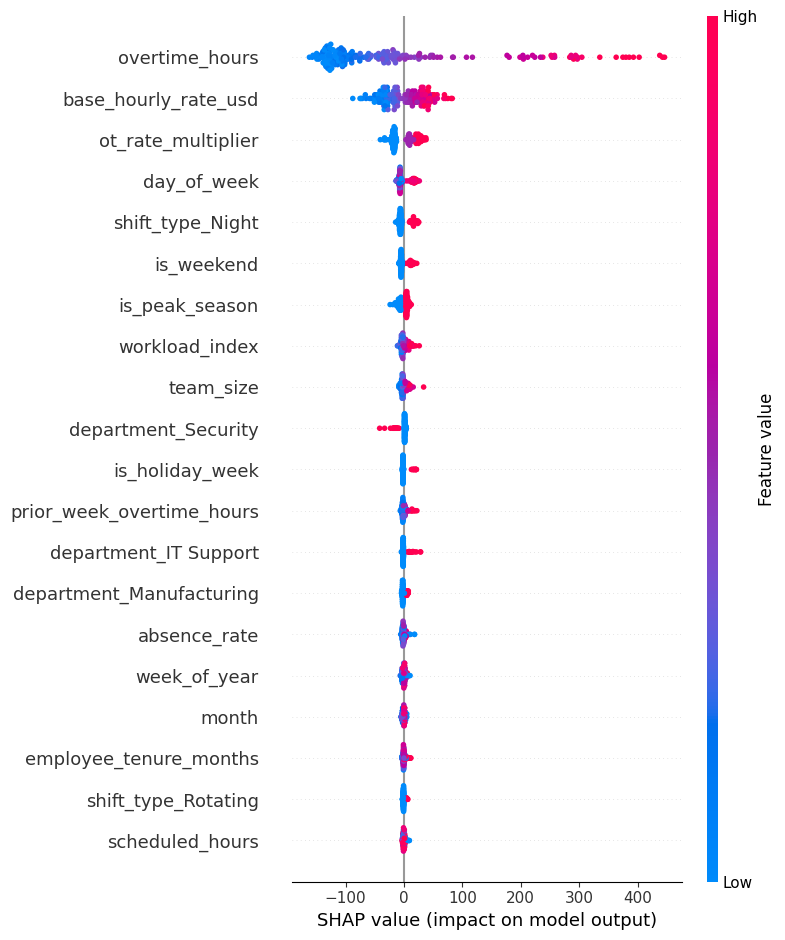

In [37]:
# Summary plot
shap.
shap.summary_plot(shap_values, sample_X)

In [38]:
# save model
joblib.dump(model, "overtime_cost_model.pkl")

['overtime_cost_model.pkl']

In [39]:
print("\nModel saved as 'overtime_cost_model.pkl'")


Model saved as 'overtime_cost_model.pkl'
